In [1]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from pyfrechet.metric_spaces import H2
import matplotlib.pyplot as plt
import seaborn as sns

## Functions

In [2]:
def pb_coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'kappa', 'OOB_quantile', 'i_cov', 'ii_cov', 'iii_cov', 'iv_cov'])
    i = 0
    for file in os.listdir(os.path.join(os.getcwd(), 'results')):
        if (file.endswith('.npy')):# and file.split('_')[3][5:] == '100'):
            print(i)
            i+=1
            infile=open(os.path.join(os.getcwd(), 'results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'kappa': file.split('_')[3][5:],
            'i_cov': [result['i_cov']],
            'ii_cov': [result['ii_cov']],
            'iii_cov': [result['iii_cov']],
            'iv_cov': [result['iv_cov']],
            'OOB_quantile': [result['OOB_quantile']],
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['kappa'] = coverage_df.kappa.astype('category')
    return coverage_df

# Parameters
sample_sizes = [50, 100, 200, 500]  # Sample sizes
kappa_values = [50, 200]  # Concentration parameters
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

In [4]:
def pb_coverage_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'train_size', 'kappa', 'OOB_quantile', 'i_cov', 'ii_cov', 'iii_cov', 'iv_cov'])
    i = 0
    for file in os.listdir(os.path.join(os.getcwd(), 'kyky')):
        if (file.endswith('.npy')):# and file.split('_')[3][5:] == '100'):
            print(i)
            i+=1
            infile=open(os.path.join(os.getcwd(), 'kyky/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'train_size': int(file.split('_')[2][1:]),
            'kappa': file.split('_')[3][5:],
            'i_cov': [result['i_cov']],
            'ii_cov': [result['ii_cov']],
            'iii_cov': [result['iii_cov']],
            'iv_cov': [result['iv_cov']],
            'OOB_quantile': [result['OOB_quantile']],
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    coverage_df['train_size'] = coverage_df['train_size'].astype('category')
    coverage_df['kappa'] = coverage_df.kappa.astype('category')
    return coverage_df

# Parameters
sample_sizes = [50, 100, 200, 500]  # Sample sizes
kappa_values = [50, 200]  # Concentration parameters
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

Prediction balls

In [5]:
# Define confidence levels
M = H2(2)
np.random.seed(1000)
sign_level = np.array([0.01, 0.05, 0.1])
# Load stored results
pb_coverage_df=pb_coverage_results()
pb_coverage_df.head()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43


,sample_index,train_size,kappa,OOB_quantile,i_cov,ii_cov,iii_cov,iv_cov
0,17,200,200,"[0.22991462658111378, 0.18550094674708073, 0.1...","[[True, True, True], [True, True, True], [True...","[0.981, 0.949, 0.883]","[[True, True, True], [True, True, False], [Tru...","[0.945, 0.836, 0.725]"
1,19,50,200,"[0.20511973035955086, 0.19050209429466164, 0.1...","[[True, True, True], [True, True, True], [True...","[0.945, 0.93, 0.861]","[[True, True, True], [True, True, False], [Tru...","[0.99, 0.978, 0.931]"
2,11,50,200,"[0.25035195035948243, 0.21216881628585313, 0.1...","[[True, True, True], [True, True, True], [True...","[0.995, 0.976, 0.921]","[[True, True, True], [True, True, False], [Tru...","[1.0, 0.996, 0.934]"
3,10,200,50,"[0.43006745925326306, 0.36288717302275764, 0.3...","[[True, True, True], [True, True, True], [True...","[0.989, 0.956, 0.884]","[[True, True, True], [True, True, True], [True...","[0.99, 0.961, 0.896]"
4,14,200,50,"[0.43892261578813874, 0.32554621188421107, 0.2...","[[True, True, True], [True, True, True], [True...","[0.994, 0.929, 0.874]","[[True, True, True], [True, True, True], [True...","[0.993, 0.943, 0.898]"


# TYPE I

In [23]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_i_coverage(pb_coverage_df, sample_sizes, kappa_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    pb_diccionario_i = {
    'kappa_50': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'kappa_200': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

    for N in sample_sizes:
        for kappa in kappa_values:
            means = []
            pb_coverage_df_N_kappa = pb_coverage_df[(pb_coverage_df['kappa'] == str(kappa)) 
            & (pb_coverage_df['train_size'] == N)
            ]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(500):
                # Extract the i-th row from each 50x3 DataFrame in pb_coverage_df['i_cov']
                row_data = pb_coverage_df_N_kappa['i_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                row_mean = row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                means.append(row_mean)

            pb_diccionario_i['kappa_' + str(kappa)][str(N)] = means
    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return pb_diccionario_i

sample_sizes = [50, 100, 200, 500]  # Sample sizes
kappa_values = [50, 200]  # Concentration parameters

pb_diccionario_i = calculate_type_i_coverage(pb_coverage_df = pb_coverage_df, sample_sizes = sample_sizes, kappa_values = kappa_values)
pb_diccionario_i

{'kappa_50': {'50': [array([0.979, 0.933, 0.878]),
   array([0.974, 0.934, 0.881]),
   array([0.983, 0.945, 0.881]),
   array([0.98 , 0.939, 0.876]),
   array([0.986, 0.945, 0.883]),
   array([0.972, 0.933, 0.869]),
   array([0.985, 0.953, 0.892]),
   array([0.982, 0.944, 0.885]),
   array([0.974, 0.937, 0.883]),
   array([0.976, 0.94 , 0.881]),
   array([0.982, 0.948, 0.885]),
   array([0.974, 0.938, 0.879]),
   array([0.98 , 0.933, 0.868]),
   array([0.977, 0.943, 0.871]),
   array([0.974, 0.933, 0.877]),
   array([0.975, 0.935, 0.879]),
   array([0.978, 0.938, 0.873]),
   array([0.985, 0.939, 0.884]),
   array([0.972, 0.932, 0.866]),
   array([0.97 , 0.933, 0.868]),
   array([0.988, 0.951, 0.899]),
   array([0.984, 0.939, 0.876]),
   array([0.983, 0.939, 0.887]),
   array([0.985, 0.947, 0.875]),
   array([0.977, 0.939, 0.879]),
   array([0.98 , 0.93 , 0.868]),
   array([0.982, 0.947, 0.89 ]),
   array([0.977, 0.938, 0.879]),
   array([0.974, 0.939, 0.892]),
   array([0.981, 0.923, 0

In [6]:
import pandas as pd
import numpy as np

def calculate_type_i_coverage(pb_coverage_df, sample_sizes, kappa_values, B=500, random_seed=1):
    """
    Calculate Type I coverage using bootstrap procedure.
    
    Parameters:
    -----------
    pb_coverage_df : DataFrame
        Coverage results dataframe
    sample_sizes : list
        List of sample sizes to analyze
    kappa_values : list
        List of kappa values to analyze
    B : int
        Number of bootstrap replicates (default: 1000)
    
    Returns:
    --------
    dict : Bootstrap results with means and standard deviations
    """

    if random_seed is not None:
        np.random.seed(random_seed)
    
    pb_diccionario_i = {
        'kappa_50': {'50': {'means': np.zeros(3), 'stds': np.zeros(3)}, 
                     '100': {'means': np.zeros(3), 'stds': np.zeros(3)}, 
                     '200': {'means': np.zeros(3), 'stds': np.zeros(3)}, 
                     '500': {'means': np.zeros(3), 'stds': np.zeros(3)}},
        'kappa_200': {'50': {'means': np.zeros(3), 'stds': np.zeros(3)}, 
                      '100': {'means': np.zeros(3), 'stds': np.zeros(3)}, 
                      '200': {'means': np.zeros(3), 'stds': np.zeros(3)}, 
                      '500': {'means': np.zeros(3), 'stds': np.zeros(3)}}
    }

    for N in sample_sizes:
        for kappa in kappa_values:
            print(f"Processing N={N}, kappa={kappa}")
            
            # Filter data for current N and kappa
            pb_coverage_df_N_kappa = pb_coverage_df[
                (pb_coverage_df['kappa'] == str(kappa)) & 
                (pb_coverage_df['train_size'] == N)
            ]
            
            # Get M (number of samples for this N, kappa combination) and assert it is 1000
            M = len(pb_coverage_df_N_kappa)
            print(M)
            #assert M == 1000, f"Expected M to be 1000, but got {M} for N={N}, kappa={kappa}"
            
            # Bootstrap procedure
            bootstrap_estimates = []  # Will store B bootstrap estimates
            
            for b in range(B):
                # Sample M indices for test pairs (i_1^(b), ..., i_M^(b))
                i_indices = np.random.choice(M, size=M, replace=True)
                
                # Sample M indices for training samples (j_1^(b), ..., j_M^(b))
                j_indices = np.random.choice(M, size=M, replace=True)
                
                # Extract bootstrap sample
                bootstrap_coverages = []
                
                for m in range(M):
                    # Extract row j_m^(b) of the dataset (training sample)
                    training_sample_idx = j_indices[m]
                    training_sample = pb_coverage_df_N_kappa.iloc[training_sample_idx]
                    
                    # Extract element i_m^(b) from the i_cov column (test pair)
                    test_pair_idx = i_indices[m]
                    coverage_for_this_pair = training_sample['i_cov'][test_pair_idx, :]  # Shape: (3,)
                    
                    bootstrap_coverages.append(coverage_for_this_pair)
                
                # Convert to array and compute mean across the M bootstrap samples
                bootstrap_coverages = np.array(bootstrap_coverages)  # Shape: (M, 3)
                p_hat_M_b = np.mean(bootstrap_coverages, axis=0)  # Shape: (3,)
                
                bootstrap_estimates.append(p_hat_M_b)
            
            # Convert bootstrap estimates to array
            bootstrap_estimates = np.array(bootstrap_estimates)  # Shape: (B, 3)
            
            # Compute overall mean and standard deviation
            p_bar_M = np.mean(bootstrap_estimates, axis=0)  # Shape: (3,)
            sigma_boot = np.std(bootstrap_estimates, axis=0, ddof=1)  # Shape: (3,)
            
            # Store results
            kappa_key = f'kappa_{kappa}'
            N_key = str(N)
            pb_diccionario_i[kappa_key][N_key]['means'] = p_bar_M
            pb_diccionario_i[kappa_key][N_key]['stds'] = sigma_boot
            
            print(f" Bootstrap means: {p_bar_M}")
            print(f" Bootstrap stds: {sigma_boot}")
    
    return pb_diccionario_i

# Usage
sample_sizes = [50, 100, 200, 500]
kappa_values = [50, 200]

pb_diccionario_i = calculate_type_i_coverage(
    pb_coverage_df=pb_coverage_df, 
    sample_sizes=sample_sizes, 
    kappa_values=kappa_values,
    B=500,  # Number of bootstrap replicates
    random_seed=1  # Optional: set a random seed for reproducibility
)

Processing N=50, kappa=50
6
 Bootstrap means: [1.         0.92466667 0.87333333]
 Bootstrap stds: [0.         0.10494562 0.12948694]
Processing N=50, kappa=200
7
 Bootstrap means: [0.97485714 0.89342857 0.77285714]
 Bootstrap stds: [0.05809119 0.12213625 0.16038352]
Processing N=100, kappa=50
6
 Bootstrap means: [1.         1.         0.97833333]
 Bootstrap stds: [0.         0.         0.05900817]
Processing N=100, kappa=200
7
 Bootstrap means: [1.         0.98114286 0.98114286]
 Bootstrap stds: [0.         0.05087593 0.05087593]
Processing N=200, kappa=50
5
 Bootstrap means: [1. 1. 1.]
 Bootstrap stds: [0. 0. 0.]
Processing N=200, kappa=200
6
 Bootstrap means: [1.    1.    0.857]
 Bootstrap stds: [0.         0.         0.13976592]
Processing N=500, kappa=50
4
 Bootstrap means: [1. 1. 1.]
 Bootstrap stds: [0. 0. 0.]
Processing N=500, kappa=200
3
 Bootstrap means: [1.         1.         0.89266667]
 Bootstrap stds: [0.         0.         0.17728877]


Prediction balls

In [24]:
# Prepare data for the DataFrame
rows = []
index = []

for kappa in [50, 200]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(pb_diccionario_i[f'kappa_{kappa}'][str(N)], axis=0)
        stds = np.sqrt(np.var(pb_diccionario_i[f'kappa_{kappa}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{kappa}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["kappa", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=[r"Significance Level"]
)

# Create the DataFrame
df = pd.DataFrame(rows, index=row_index, columns=col_index)

# Display the DataFrame
df

Significance Level          0.01          0.05           0.1
kappa N                                                     
50    50            97.85 (0.45)  93.75 (0.76)  87.80 (0.97)
      100           97.89 (0.43)  93.71 (0.76)  88.71 (0.94)
      200           98.41 (0.39)  94.46 (0.71)  89.41 (0.98)
      500           98.81 (0.34)  94.80 (0.69)  89.84 (0.95)
200   50            98.14 (0.41)  94.22 (0.74)  88.39 (1.00)
      100           97.81 (0.46)  93.86 (0.76)  88.87 (1.05)
      200           98.42 (0.38)  94.32 (0.75)  89.18 (1.01)
      500           98.80 (0.33)  94.82 (0.70)  89.87 (0.93)

In [25]:
import pandas as pd
def format_cell(value):
    mean, std = value.split(" ")
    mean = f"{float(mean):.2f}"
    std = std.strip("()")
    std = f"({float(std):.2f})"
    return f"{mean} {std}"

# Apply formatting to all cells
df = df.applymap(format_cell)

latex = df.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption='Type I error', label='tab:typeIerrorcoverage')

/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_29042/2912561022.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(format_cell)


In [26]:
print(latex)

\begin{table}
\caption{Type I error}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
kappa & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{50}} & \textbf{50} & 97.85 (0.45) & 93.75 (0.76) & 87.80 (0.97) \\
\textbf{} & \textbf{100} & 97.89 (0.43) & 93.71 (0.76) & 88.71 (0.94) \\
\textbf{} & \textbf{200} & 98.41 (0.39) & 94.46 (0.71) & 89.41 (0.98) \\
\textbf{} & \textbf{500} & 98.81 (0.34) & 94.80 (0.69) & 89.84 (0.95) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{200}} & \textbf{50} & 98.14 (0.41) & 94.22 (0.74) & 88.39 (1.00) \\
\textbf{} & \textbf{100} & 97.81 (0.46) & 93.86 (0.76) & 88.87 (1.05) \\
\textbf{} & \textbf{200} & 98.42 (0.38) & 94.32 (0.75) & 89.18 (1.01) \\
\textbf{} & \textbf{500} & 98.80 (0.33) & 94.82 (0.70) & 89.87 (0.93) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



# TYPE II

### KAPPA 50

In [8]:
ii_pb_coverage_df_kappa_50_alpha_01 = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()
ii_pb_coverage_df_kappa_50_alpha_05 = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()
ii_pb_coverage_df_kappa_50_alpha_1  = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()

ii_pb_coverage_df_kappa_50_alpha_01['ii_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['ii_cov'].apply(lambda x: x[0])
ii_pb_coverage_df_kappa_50_alpha_01['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[0])

ii_pb_coverage_df_kappa_50_alpha_05['ii_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['ii_cov'].apply(lambda x: x[1])
ii_pb_coverage_df_kappa_50_alpha_05['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[1])

ii_pb_coverage_df_kappa_50_alpha_1['ii_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['ii_cov'].apply(lambda x: x[2])
ii_pb_coverage_df_kappa_50_alpha_1['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[2])

ii_pb_coverage_df_kappa_50_alpha_01.head()
ii_pb_coverage_df_kappa_50_alpha_05.head()
ii_pb_coverage_df_kappa_50_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,i_cov,ii_cov,iii_cov,iv_cov
2,573,100,50,0.294886,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.871,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.995, 0.945, 0.881]"
3,39,100,50,0.324766,"[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...",0.904,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.968, 0.93]"
4,887,200,50,0.309330,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.883,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.989, 0.947, 0.908]"
6,819,50,50,0.335787,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.895,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.997, 0.973, 0.941]"
7,86,200,50,0.306221,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.889,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.989, 0.966, 0.912]"


In [9]:
ii_pb_coverage_df_kappa_200_alpha_01 = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()
ii_pb_coverage_df_kappa_200_alpha_05 = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()
ii_pb_coverage_df_kappa_200_alpha_1  = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()

ii_pb_coverage_df_kappa_200_alpha_01['ii_cov'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['ii_cov'].apply(lambda x: x[0])
ii_pb_coverage_df_kappa_200_alpha_01['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[0])

ii_pb_coverage_df_kappa_200_alpha_05['ii_cov'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['ii_cov'].apply(lambda x: x[1])
ii_pb_coverage_df_kappa_200_alpha_05['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[1])

ii_pb_coverage_df_kappa_200_alpha_1['ii_cov'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['ii_cov'].apply(lambda x: x[2])
ii_pb_coverage_df_kappa_200_alpha_1['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[2])

ii_pb_coverage_df_kappa_200_alpha_01.head()
ii_pb_coverage_df_kappa_200_alpha_05.head()
ii_pb_coverage_df_kappa_200_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,i_cov,ii_cov,iii_cov,iv_cov
0,212,200,200,0.158166,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.907,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.995, 0.932, 0.89]"
1,410,500,200,0.153134,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [0.0, 0.0, ...",0.911,"[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.997, 0.95, 0.901]"
5,393,200,200,0.152184,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.867,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.999, 0.971, 0.901]"
10,833,50,200,0.159508,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.858,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[1.0, 0.973, 0.935]"
12,599,100,200,0.158464,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.865,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.985, 0.941, 0.871]"


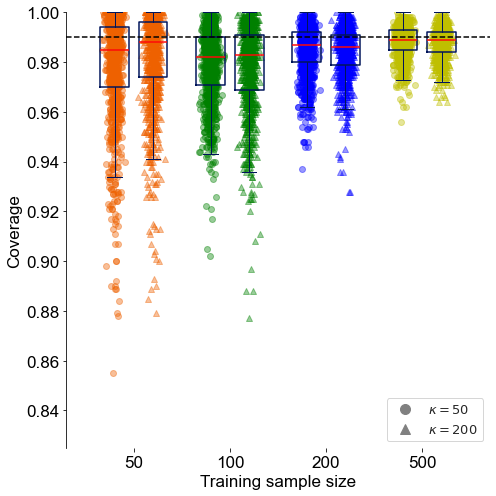

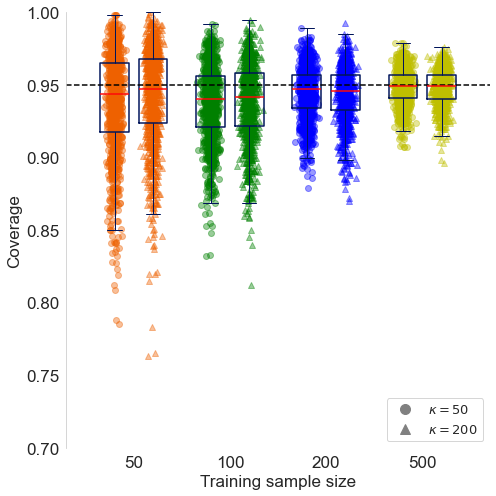

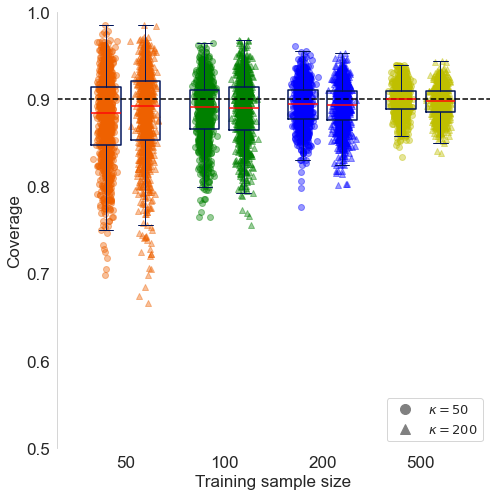

In [10]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for kappa_50_data, kappa_200_data, alpha_level in zip(
    [ii_pb_coverage_df_kappa_50_alpha_01, ii_pb_coverage_df_kappa_50_alpha_05, ii_pb_coverage_df_kappa_50_alpha_1], 
    [ii_pb_coverage_df_kappa_200_alpha_01, ii_pb_coverage_df_kappa_200_alpha_05, ii_pb_coverage_df_kappa_200_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    kappa_50_boxplot_data = [kappa_50_data[kappa_50_data['train_size'] == size]['ii_cov'].values for size in train_sizes]
    kappa_200_boxplot_data = [kappa_200_data[kappa_200_data['train_size'] == size]['ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_kappa_50 = np.array(range(len(train_sizes))) - 0.2
    positions_kappa_200 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(kappa_50_boxplot_data, positions=positions_kappa_50, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,  # Updated to hide fliers
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(kappa_200_boxplot_data, positions=positions_kappa_200, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,  # Updated to hide fliers
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_kappa_50 = ['#ee6100', 'g', 'b', 'y']
    palette_kappa_200 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_kappa_50 = np.random.normal(positions_kappa_50[i], 0.04, len(kappa_50_boxplot_data[i]))
        xs_kappa_200 = np.random.normal(positions_kappa_200[i], 0.04, len(kappa_200_boxplot_data[i]))

        ax.scatter(xs_kappa_50, kappa_50_boxplot_data[i], alpha=0.4, color=palette_kappa_50[i], label='Prediction balls')
        ax.scatter(xs_kappa_200, kappa_200_boxplot_data[i], alpha=0.4, color=palette_kappa_200[i], marker='^', label='Split-conformal')

    sns.despine(bottom=True)  # Remove right and top axis lines
    sns.set_style("whitegrid")
    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1)
    elif alpha_level == 0.05:
        ax.set_ylim(0.7, 1)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    #legend_handles = [
    #    mpatches.Patch(color=palette_kappa_50[j], label=f'Train Size: {train_sizes[j]}')
    #    for j in range(len(train_sizes))
    #]

    legend_handles = []
        
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$\kappa = 50$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$\kappa = 200$'))
    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)

    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'pb_H2_kappa_50_200_II_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

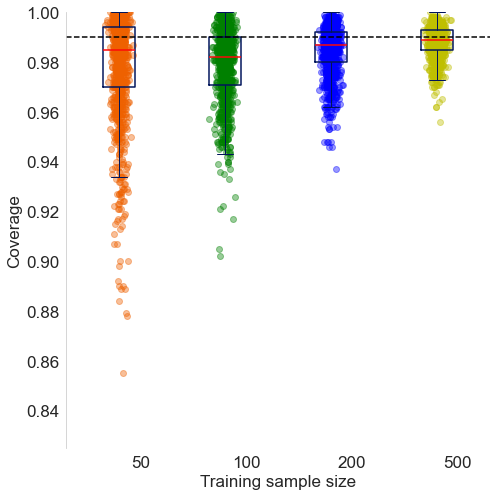

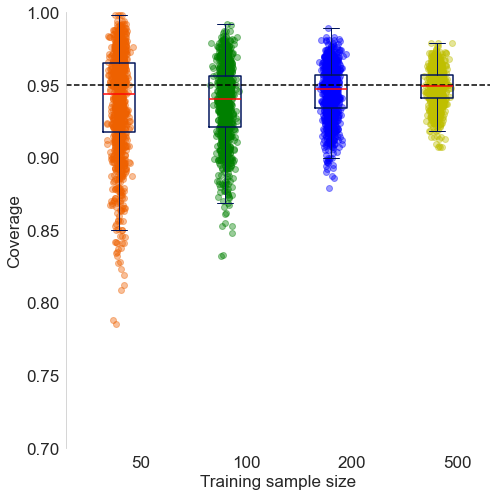

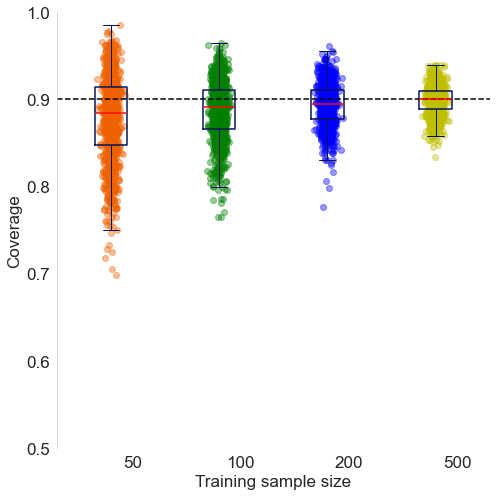

In [11]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for kappa_50_data, alpha_level in zip(
    [ii_pb_coverage_df_kappa_50_alpha_01, ii_pb_coverage_df_kappa_50_alpha_05, ii_pb_coverage_df_kappa_50_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    kappa_50_boxplot_data = [kappa_50_data[kappa_50_data['train_size'] == size]['ii_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_kappa_50 = np.array(range(len(train_sizes))) - 0.2

    ax.boxplot(kappa_50_boxplot_data, positions=positions_kappa_50, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,  # Updated to hide fliers
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    # Scatter plot
    palette_kappa_50 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_kappa_50 = np.random.normal(positions_kappa_50[i], 0.04, len(kappa_50_boxplot_data[i]))

        ax.scatter(xs_kappa_50, kappa_50_boxplot_data[i], alpha=0.4, color=palette_kappa_50[i], label='Prediction balls')

    sns.despine(bottom=True)  # Remove right and top axis lines
    sns.set_style("whitegrid")
    ax.set_xticks([0,1,2,3])
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1)
    elif alpha_level == 0.05:
        ax.set_ylim(0.7, 1)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    #legend_handles = [
    #    mpatches.Patch(color=palette_kappa_50[j], label=f'Train Size: {train_sizes[j]}')
    #    for j in range(len(train_sizes))
    #]

    legend_handles = []
        
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'provisional_H2' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

In [12]:
ii_pb_coverage_df_alpha_01 = pb_coverage_df.copy()
ii_pb_coverage_df_alpha_05 = pb_coverage_df.copy()
ii_pb_coverage_df_alpha_1  = pb_coverage_df.copy()

ii_pb_coverage_df_alpha_01['OOB_quantile'] = pb_coverage_df['OOB_quantile'].apply(lambda x: x[0])
ii_pb_coverage_df_alpha_05['OOB_quantile'] = pb_coverage_df['OOB_quantile'].apply(lambda x: x[1])
ii_pb_coverage_df_alpha_1['OOB_quantile'] = pb_coverage_df['OOB_quantile'].apply(lambda x: x[2])

ii_pb_coverage_df_alpha_01.head()
ii_pb_coverage_df_alpha_05.head()
ii_pb_coverage_df_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,i_cov,ii_cov,iii_cov,iv_cov
0,212,200,200,0.158166,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.993, 0.949, 0.907]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.995, 0.932, 0.89]"
1,410,500,200,0.153134,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [0.0, 0.0, ...","[0.989, 0.954, 0.911]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...","[0.997, 0.95, 0.901]"
2,573,100,50,0.294886,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.933, 0.871]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.995, 0.945, 0.881]"
3,39,100,50,0.324766,"[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...","[0.98, 0.942, 0.904]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.968, 0.93]"
4,887,200,50,0.309330,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.976, 0.924, 0.883]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.989, 0.947, 0.908]"


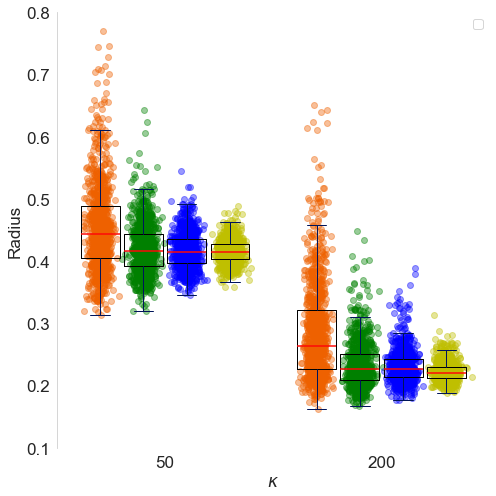

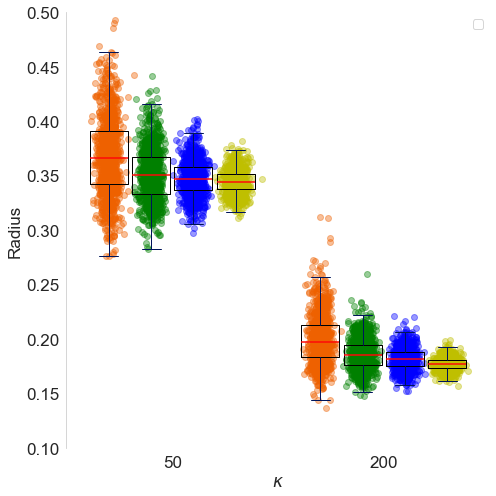

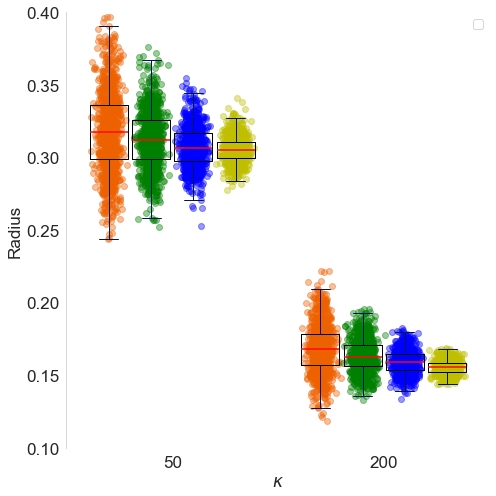

In [13]:
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip(
    [ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_pb_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_pb_coverage_df_alpha_05
    else:
        coverage_df = ii_pb_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    kappas = ['50', '200']
    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['kappa'] == kappa) & (coverage_df['train_size'] == N), 'OOB_quantile']
            for N in train_sizes]
        for kappa in kappas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False, showfliers=False) 

    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j])


    sns.despine(bottom=True) # removes right and top axis lines
    sns.set_style("whitegrid")
    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(kappas))],
        labels=kappas
    )
    ax.set_xlim(0, len(kappas) * (len(train_sizes) + 1))
    if alpha_level == 0.01:
        ax.set_ylim(0.1, 0.8)
    elif alpha_level == 0.05:
        ax.set_ylim(0.1, 0.5)
    else:
        ax.set_ylim(0.1, 0.4)
        
    ax.set_xlabel(r'$\kappa$', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    #legend_handles = [
    #    mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
    #    for j in range(len(train_sizes))
    #]

    legend_handles = []
    ax.legend(handles=legend_handles, loc='upper right', fontsize=13)
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'pb_H2_radius_vs_kappa' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

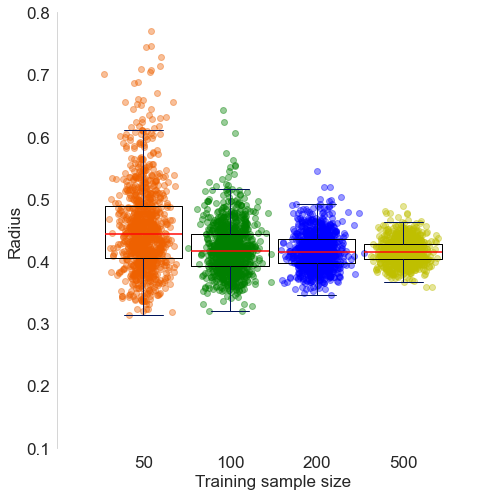

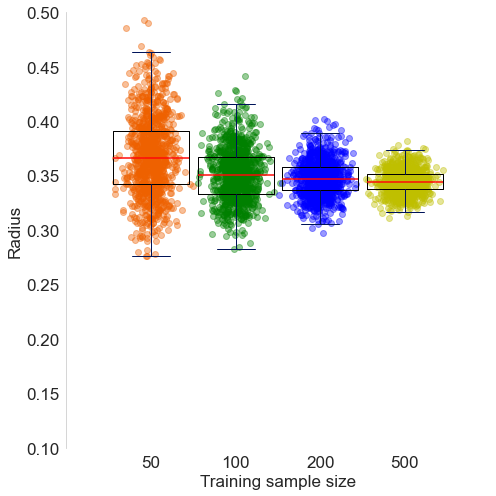

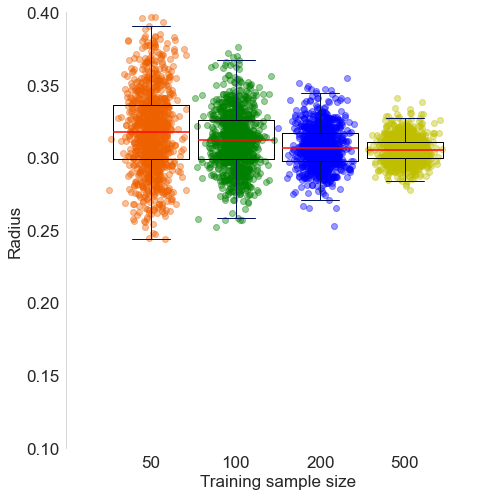

In [14]:
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for data, alpha_level in zip(
    [ii_pb_coverage_df_alpha_01, ii_pb_coverage_df_alpha_05, ii_pb_coverage_df_alpha_1], 
    [0.01, 0.05, 0.1]):
    if alpha_level == 0.01:
        coverage_df = ii_pb_coverage_df_alpha_01
    elif alpha_level == 0.05:
        coverage_df = ii_pb_coverage_df_alpha_05
    else:
        coverage_df = ii_pb_coverage_df_alpha_1

    # Extract unique train sizes and degrees of freedom
    train_sizes = sorted(coverage_df['train_size'].unique())
    kappas = ['50']
    # Prepare the data for boxplots
    grouped_data = [
        [coverage_df.loc[(coverage_df['kappa'] == kappa) & (coverage_df['train_size'] == N), 'OOB_quantile']
            for N in train_sizes]
        for kappa in kappas ]

    # Plotting
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)

    palette = ['#ee6100', 'g', 'b', 'y']  # Generate unique colors

    for i, group in enumerate(grouped_data):
        #In this loop, select the degrees of freedom
        base_position = 1 + i * (len(train_sizes) + 1)  # spacing between groups

        for j, ts_data in enumerate(group):
            #In this loop, select the train sizes. ts_data is the dataset for train size and df
            pos = base_position + j

            #ax.boxplot(ts_data, positions=[pos], widths=1, patch_artist=True, 
            #            boxprops=dict(facecolor=palette[j], alpha=.9),
            #            flierprops={'marker': 'x', 'color': 'red'})
            ax.boxplot(ts_data, positions=[pos], widths = .9, notch=False, whiskerprops=whiskerprops,capprops=capprops, flierprops=flierprops, medianprops=medianprops,showmeans=False, showfliers=False) 

    
            palette = ['#ee6100', 'g', 'b', 'y']
            for x, val in zip(np.random.normal(pos, 0.14, ts_data.shape[0]), ts_data):
                ax.scatter(x, val, alpha=0.4, color = palette[j])


    sns.despine(bottom=True) # removes right and top axis lines
    sns.set_style("whitegrid")
    # Formatting
    ax.set_xticks(
        ticks=[1 + i * (len(train_sizes) + 1) + (len(train_sizes) - 1) / 2 for i in range(len(kappas))],
        labels=kappas
    )
    ax.set_xlim(0, len(kappas) * (len(train_sizes) + 1))
    if alpha_level == 0.01:
        ax.set_ylim(0.1, 0.8)
    elif alpha_level == 0.05:
        ax.set_ylim(0.1, 0.5)
    else:
        ax.set_ylim(0.1, 0.4)

    ax.set_xticks([1,2,3,4])
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)
        
    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Radius', fontsize=17)
    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    #legend_handles = [
    #    mpatches.Patch(color=palette[j], label=f'Train Size: {train_sizes[j]}') 
    #    for j in range(len(train_sizes))
    #]

    legend_handles = []
    ax.grid(False)
    fig.tight_layout()
    
    filename = os.path.join(os.getcwd(), 'provisional_2_H2' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches = 'tight', format='pdf', transparent=True)
    plt.show()

# TYPE III

In [8]:
import pandas as pd
import numpy as np

def calculate_type_iii_coverage(pb_coverage_df, sample_sizes, kappa_values, B=500, random_seed=1):
    """
    Calculate Type III coverage using bootstrap procedure.
    
    Parameters:
    -----------
    pb_coverage_df : DataFrame
        Coverage results dataframe
    sample_sizes : list
        List of sample sizes to analyze
    kappa_values : list
        List of kappa values to analyze
    B : int
        Number of bootstrap replicates (default: 1000)
    
    Returns:
    --------
    dict : Bootstrap results with means and standard deviations
    """

    if random_seed is not None:
        np.random.seed(random_seed)
    
    pb_diccionario_iii = {
        'kappa_50': {'50': {'means': np.zeros(3), 'stds': np.zeros(3)}, 
                     '100': {'means': np.zeros(3), 'stds': np.zeros(3)}, 
                     '200': {'means': np.zeros(3), 'stds': np.zeros(3)}, 
                     '500': {'means': np.zeros(3), 'stds': np.zeros(3)}},
        'kappa_200': {'50': {'means': np.zeros(3), 'stds': np.zeros(3)}, 
                      '100': {'means': np.zeros(3), 'stds': np.zeros(3)}, 
                      '200': {'means': np.zeros(3), 'stds': np.zeros(3)}, 
                      '500': {'means': np.zeros(3), 'stds': np.zeros(3)}}
    }

    for N in sample_sizes:
        for kappa in kappa_values:
            print(f"Processing N={N}, kappa={kappa}")
            
            # Filter data for current N and kappa
            pb_coverage_df_N_kappa = pb_coverage_df[
                (pb_coverage_df['kappa'] == str(kappa)) & 
                (pb_coverage_df['train_size'] == N)
            ]
            
            # Get M (number of samples for this N, kappa combination) and assert it is 1000
            M = len(pb_coverage_df_N_kappa)
            print(M)
            #assert M == 1000, f"Expected M to be 1000, but got {M} for N={N}, kappa={kappa}"
            
            # Bootstrap procedure
            bootstrap_estimates = []  # Will store B bootstrap estimates
            
            for b in range(B):
                # Sample M indices for test pairs (i_1^(b), ..., i_M^(b))
                i_indices = np.random.choice(M, size=M, replace=True)
                
                # Sample M indices for training samples (j_1^(b), ..., j_M^(b))
                j_indices = np.random.choice(M, size=M, replace=True)
                
                # Extract bootstrap sample
                bootstrap_coverages = []
                
                for m in range(M):
                    # Extract row j_m^(b) of the dataset (training sample)
                    training_sample_idx = j_indices[m]
                    training_sample = pb_coverage_df_N_kappa.iloc[training_sample_idx]
                    
                    # Extract element i_m^(b) from the i_cov column (test pair)
                    test_pair_idx = i_indices[m]
                    coverage_for_this_pair = training_sample['iii_cov'][test_pair_idx, :]  # Shape: (3,)
                    
                    bootstrap_coverages.append(coverage_for_this_pair)
                
                # Convert to array and compute mean across the M bootstrap samples
                bootstrap_coverages = np.array(bootstrap_coverages)  # Shape: (M, 3)
                p_hat_M_b = np.mean(bootstrap_coverages, axis=0)  # Shape: (3,)
                
                bootstrap_estimates.append(p_hat_M_b)
            
            # Convert bootstrap estimates to array
            bootstrap_estimates = np.array(bootstrap_estimates)  # Shape: (B, 3)
            
            # Compute overall mean and standard deviation
            p_bar_M = np.mean(bootstrap_estimates, axis=0)  # Shape: (3,)
            sigma_boot = np.std(bootstrap_estimates, axis=0, ddof=1)  # Shape: (3,)
            
            # Store results
            kappa_key = f'kappa_{kappa}'
            N_key = str(N)
            pb_diccionario_iii[kappa_key][N_key]['means'] = p_bar_M
            pb_diccionario_iii[kappa_key][N_key]['stds'] = sigma_boot
            
            print(f"  Bootstrap means: {p_bar_M}")
            print(f"  Bootstrap stds: {sigma_boot}")
    
    return pb_diccionario_i

# Usage
sample_sizes = [50, 100, 200, 500]
kappa_values = [50, 200]

pb_diccionario_iii = calculate_type_iii_coverage(
    pb_coverage_df=pb_coverage_df, 
    sample_sizes=sample_sizes, 
    kappa_values=kappa_values,
    B=500,  # Number of bootstrap replicates
    random_seed=1  # Optional: set a random seed for reproducibility
)

Processing N=50, kappa=50
6
  Bootstrap means: [1. 1. 1.]
  Bootstrap stds: [0. 0. 0.]
Processing N=50, kappa=200
7
  Bootstrap means: [0.97914286 0.96057143 0.82457143]
  Bootstrap stds: [0.05286832 0.07564482 0.14328707]
Processing N=100, kappa=50
6
  Bootstrap means: [0.94666667 0.82766667 0.76933333]
  Bootstrap stds: [0.08790088 0.15622288 0.17277903]
Processing N=100, kappa=200
7
  Bootstrap means: [0.944      0.80114286 0.63371429]
  Bootstrap stds: [0.08268529 0.15496473 0.19088809]
Processing N=200, kappa=50
5
  Bootstrap means: [1.     0.9596 0.7956]
  Bootstrap stds: [0.         0.0897996  0.17698386]
Processing N=200, kappa=200
6
  Bootstrap means: [1.         1.         0.94866667]
  Bootstrap stds: [0.         0.         0.09094129]
Processing N=500, kappa=50
4
  Bootstrap means: [1. 1. 1.]
  Bootstrap stds: [0. 0. 0.]
Processing N=500, kappa=200
3
  Bootstrap means: [1. 1. 1.]
  Bootstrap stds: [0. 0. 0.]


In [27]:
import pandas as pd
import numpy as np

zeros_init = np.zeros((50, 3))

def calculate_type_iii_coverage(pb_coverage_df, sample_sizes, kappa_values):
    # Initialize a list to store the means for each row (50 rows of 3 means)
    pb_diccionario_iii = {
    'kappa_50': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init},
    'kappa_200': {'50': zeros_init, '100': zeros_init, '200': zeros_init, '500': zeros_init}
    }

    for N in sample_sizes:
        for kappa in kappa_values:
            means = []
            pb_coverage_df_N_kappa = pb_coverage_df[(pb_coverage_df['kappa'] == str(kappa)) 
            & (pb_coverage_df['train_size'] == N)
            ]
            # Loop through each of the 50 rows (indices 0 through 49)
            for i in range(500):
                # Extract the i-th row from each 50x3 DataFrame in pb_coverage_df['i_cov']
                row_data = pb_coverage_df_N_kappa['iii_cov'].apply(lambda df: df[i])
                # Calculate the mean of the 3 columns for this row (axis=0 is for columns)
                row_mean = row_data.mean(axis=0)
                # Append the mean of this row (3 values) to the list
                means.append(row_mean)

            pb_diccionario_iii['kappa_' + str(kappa)][str(N)] = means
    # mean_df now contains the 50x3 means where each row corresponds to a row of means for the respective 
    return pb_diccionario_iii

sample_sizes = [50, 100, 200, 500]  # Sample sizes
kappa_values = [50, 200]  # Concentration parameters

pb_diccionario_iii = calculate_type_iii_coverage(pb_coverage_df = pb_coverage_df, sample_sizes = sample_sizes, kappa_values = kappa_values)
pb_diccionario_iii

{'kappa_50': {'50': [array([0.985, 0.96 , 0.911]),
   array([0.977, 0.949, 0.898]),
   array([0.985, 0.946, 0.887]),
   array([0.99 , 0.949, 0.904]),
   array([0.994, 0.956, 0.905]),
   array([0.987, 0.957, 0.905]),
   array([0.986, 0.962, 0.907]),
   array([0.982, 0.944, 0.893]),
   array([0.98 , 0.938, 0.891]),
   array([0.982, 0.934, 0.879]),
   array([0.985, 0.958, 0.897]),
   array([0.985, 0.953, 0.894]),
   array([0.982, 0.938, 0.878]),
   array([0.987, 0.95 , 0.889]),
   array([0.982, 0.951, 0.897]),
   array([0.982, 0.946, 0.901]),
   array([0.982, 0.95 , 0.891]),
   array([0.987, 0.949, 0.888]),
   array([0.985, 0.953, 0.894]),
   array([0.985, 0.951, 0.888]),
   array([0.989, 0.955, 0.897]),
   array([0.988, 0.957, 0.905]),
   array([0.99 , 0.954, 0.892]),
   array([0.987, 0.953, 0.896]),
   array([0.982, 0.95 , 0.887]),
   array([0.99 , 0.958, 0.905]),
   array([0.985, 0.947, 0.897]),
   array([0.976, 0.936, 0.873]),
   array([0.992, 0.948, 0.889]),
   array([0.98 , 0.946, 0

In [28]:
# Prepare data for the DataFrame
rows = []
index = []

for kappa in [50, 200]:
    for N in [50, 100, 200, 500]:
        row = []
        means = np.mean(pb_diccionario_iii[f'kappa_{kappa}'][str(N)], axis=0)
        stds = np.sqrt(np.var(pb_diccionario_iii[f'kappa_{kappa}'][str(N)], axis=0))
        # Format as "mean (std)"
        formatted_values = [f"{100*means[i]:.2f} ({100*stds[i]:.2f})" for i in range(3)]
        row.extend(formatted_values)
        rows.append(row)
        index.append((f"{kappa}", f"{N}"))

# MultiIndex for rows and columns
row_index = pd.MultiIndex.from_tuples(index, names=["kappa", "N"])
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"]],
    names=["Significance Level"]
)

# Create the DataFrame
pb_df_iii = pd.DataFrame(rows, index=row_index, columns=col_index)
# Display the DataFrame
pb_df_iii

Significance Level          0.01          0.05           0.1
kappa N                                                     
50    50            98.48 (0.37)  94.88 (0.67)  89.26 (1.02)
      100           98.36 (0.39)  94.52 (0.73)  89.79 (0.97)
      200           98.72 (0.35)  94.93 (0.65)  90.02 (0.89)
      500           98.96 (0.32)  95.23 (0.69)  90.35 (0.95)
200   50            99.29 (0.27)  96.32 (0.58)  90.97 (0.84)
      100           98.72 (0.36)  95.22 (0.63)  90.41 (0.87)
      200           99.10 (0.30)  95.36 (0.65)  90.33 (0.92)
      500           99.25 (0.27)  95.53 (0.65)  90.58 (0.89)

In [29]:
# Apply formatting to all cells
pb_latex_iii= pb_df_iii.applymap(format_cell)

pb_latex_iii = pb_latex_iii.to_latex(index=True, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, float_format= "%.3f" , caption=r'Type I error coverage for differentvalues of $\sigma$ and sample sizes', label='tab:typeIerrorcoverage')
print(pb_latex_iii)

\begin{table}
\caption{Type I error coverage for differentvalues of $\sigma$ and sample sizes}
\label{tab:typeIerrorcoverage}
\begin{tabular}{lllll}
\toprule
 & Significance Level & ('0.01',) & ('0.05',) & ('0.1',) \\
kappa & N &  &  &  \\
\midrule
\multirow[t]{4}{*}{\textbf{50}} & \textbf{50} & 98.48 (0.37) & 94.88 (0.67) & 89.26 (1.02) \\
\textbf{} & \textbf{100} & 98.36 (0.39) & 94.52 (0.73) & 89.79 (0.97) \\
\textbf{} & \textbf{200} & 98.72 (0.35) & 94.93 (0.65) & 90.02 (0.89) \\
\textbf{} & \textbf{500} & 98.96 (0.32) & 95.23 (0.69) & 90.35 (0.95) \\
\cline{1-5}
\multirow[t]{4}{*}{\textbf{200}} & \textbf{50} & 99.29 (0.27) & 96.32 (0.58) & 90.97 (0.84) \\
\textbf{} & \textbf{100} & 98.72 (0.36) & 95.22 (0.63) & 90.41 (0.87) \\
\textbf{} & \textbf{200} & 99.10 (0.30) & 95.36 (0.65) & 90.33 (0.92) \\
\textbf{} & \textbf{500} & 99.25 (0.27) & 95.53 (0.65) & 90.58 (0.89) \\
\cline{1-5}
\bottomrule
\end{tabular}
\end{table}



/var/folders/z_/bb464vm54_vcx10blg24_d7m0000gn/T/ipykernel_29042/2774234259.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pb_latex_iii= pb_df_iii.applymap(format_cell)


# Type IV

Hacemos todo con $(\pi/2, \pi/2, \pi/2)$.

In [18]:
iv_pb_coverage_df_kappa_50_alpha_01 = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()
iv_pb_coverage_df_kappa_50_alpha_05 = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()
iv_pb_coverage_df_kappa_50_alpha_1  = pb_coverage_df[pb_coverage_df['kappa'] == '50'].copy()

iv_pb_coverage_df_kappa_50_alpha_01['iv_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['iv_cov'].apply(lambda x: x[0])
iv_pb_coverage_df_kappa_50_alpha_01['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[0])

iv_pb_coverage_df_kappa_50_alpha_05['iv_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['iv_cov'].apply(lambda x: x[1])
iv_pb_coverage_df_kappa_50_alpha_05['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[1])

iv_pb_coverage_df_kappa_50_alpha_1['iv_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '50']['iv_cov'].apply(lambda x: x[2])
iv_pb_coverage_df_kappa_50_alpha_1['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '50']['OOB_quantile'].apply(lambda x: x[2])

iv_pb_coverage_df_kappa_50_alpha_01.head()
iv_pb_coverage_df_kappa_50_alpha_05.head()
iv_pb_coverage_df_kappa_50_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,i_cov,ii_cov,iii_cov,iv_cov
2,573,100,50,0.294886,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.933, 0.871]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.881
3,39,100,50,0.324766,"[[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [1.0, 1.0, ...","[0.98, 0.942, 0.904]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.930
4,887,200,50,0.309330,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.976, 0.924, 0.883]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.908
6,819,50,50,0.335787,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.99, 0.939, 0.895]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.941
7,86,200,50,0.306221,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.984, 0.948, 0.889]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.912


In [19]:
iv_pb_coverage_df_kappa_200_alpha_01 = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()
iv_pb_coverage_df_kappa_200_alpha_05 = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()
iv_pb_coverage_df_kappa_200_alpha_1  = pb_coverage_df[pb_coverage_df['kappa'] == '200'].copy()

iv_pb_coverage_df_kappa_200_alpha_01['iv_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '200']['iv_cov'].apply(lambda x: x[0])
iv_pb_coverage_df_kappa_200_alpha_01['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[0])

iv_pb_coverage_df_kappa_200_alpha_05['iv_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '200']['iv_cov'].apply(lambda x: x[1])
iv_pb_coverage_df_kappa_200_alpha_05['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[1])

iv_pb_coverage_df_kappa_200_alpha_1['iv_cov']  = pb_coverage_df[pb_coverage_df['kappa'] == '200']['iv_cov'].apply(lambda x: x[2])
iv_pb_coverage_df_kappa_200_alpha_1['OOB_quantile'] = pb_coverage_df[pb_coverage_df['kappa'] == '200']['OOB_quantile'].apply(lambda x: x[2])

iv_pb_coverage_df_kappa_200_alpha_01.head()
iv_pb_coverage_df_kappa_200_alpha_05.head()
iv_pb_coverage_df_kappa_200_alpha_1.head()

,sample_index,train_size,kappa,OOB_quantile,i_cov,ii_cov,iii_cov,iv_cov
0,212,200,200,0.158166,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.993, 0.949, 0.907]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.890
1,410,500,200,0.153134,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [0.0, 0.0, ...","[0.989, 0.954, 0.911]","[[1.0, 1.0, 1.0], [1.0, 0.0, 0.0], [1.0, 1.0, ...",0.901
5,393,200,200,0.152184,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.992, 0.935, 0.867]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.901
10,833,50,200,0.159508,"[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.997, 0.922, 0.858]","[[1.0, 0.0, 0.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.935
12,599,100,200,0.158464,"[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...","[0.982, 0.941, 0.865]","[[1.0, 1.0, 1.0], [1.0, 1.0, 1.0], [1.0, 1.0, ...",0.871


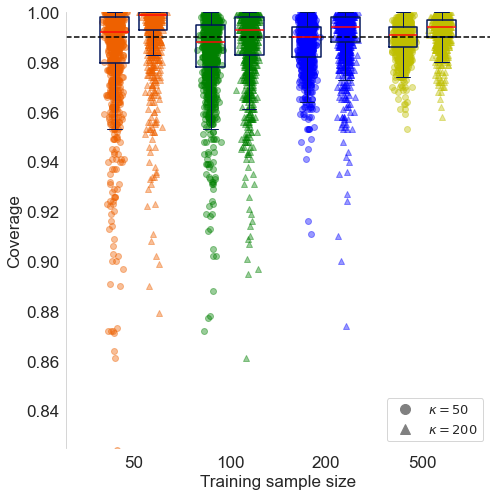

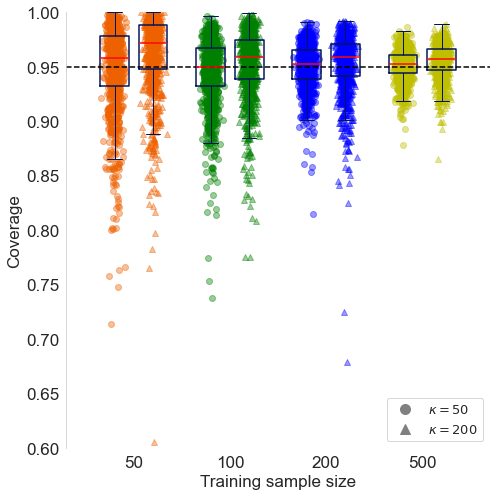

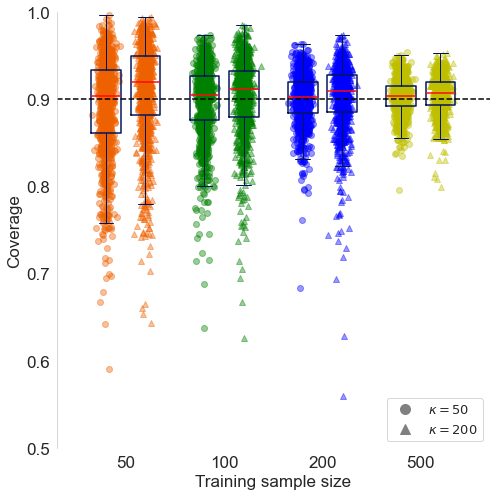

In [20]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')



for kappa_50_data, kappa_200_data, alpha_level in zip(
    [iv_pb_coverage_df_kappa_50_alpha_01, iv_pb_coverage_df_kappa_50_alpha_05, iv_pb_coverage_df_kappa_50_alpha_1], 
    [iv_pb_coverage_df_kappa_200_alpha_01, iv_pb_coverage_df_kappa_200_alpha_05, iv_pb_coverage_df_kappa_200_alpha_1], 
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)
    sns.despine(bottom=True)  # Remove right and top axis lines
    sns.set_style("whitegrid")
    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    kappa_50_boxplot_data = [kappa_50_data[kappa_50_data['train_size'] == size]['iv_cov'].values for size in train_sizes]
    kappa_200_boxplot_data = [kappa_200_data[kappa_200_data['train_size'] == size]['iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_kappa_50 = np.array(range(len(train_sizes))) - 0.2
    positions_kappa_200 = np.array(range(len(train_sizes))) + 0.2

    ax.boxplot(kappa_50_boxplot_data, positions=positions_kappa_50, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,  # Updated to hide fliers
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    ax.boxplot(kappa_200_boxplot_data, positions=positions_kappa_200, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,  # Updated to hide fliers
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)

    # Scatter plot
    palette_kappa_50 = ['#ee6100', 'g', 'b', 'y']
    palette_kappa_200 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_kappa_50 = np.random.normal(positions_kappa_50[i], 0.04, len(kappa_50_boxplot_data[i]))
        xs_kappa_200 = np.random.normal(positions_kappa_200[i], 0.04, len(kappa_200_boxplot_data[i]))

        ax.scatter(xs_kappa_50, kappa_50_boxplot_data[i], alpha=0.4, color=palette_kappa_50[i], label='Prediction balls')
        ax.scatter(xs_kappa_200, kappa_200_boxplot_data[i], alpha=0.4, color=palette_kappa_200[i], marker='^', label='Split-conformal')

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1)
    elif alpha_level == 0.05:
        ax.set_ylim(0.6, 1)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    #legend_handles = [
    #    mpatches.Patch(color=palette_kappa_50[j], label=f'Train Size: {train_sizes[j]}')
    #    for j in range(len(train_sizes))
    #]

    legend_handles = []
        
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label=r'$\kappa = 50$'))
    legend_handles.append(mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label=r'$\kappa = 200$'))
    ax.legend(handles=legend_handles, loc='lower right', fontsize=13)

    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'pb_H2_kappa_50_200_IV_coverage_' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()

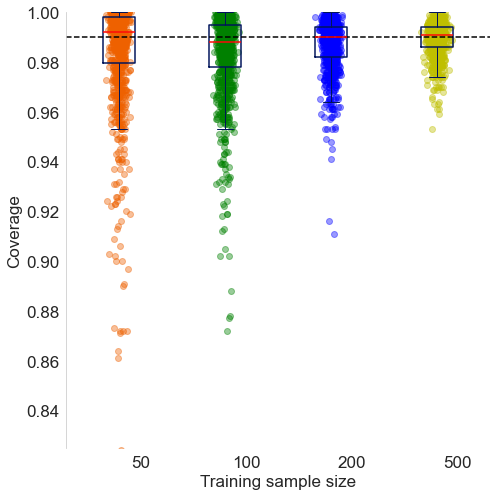

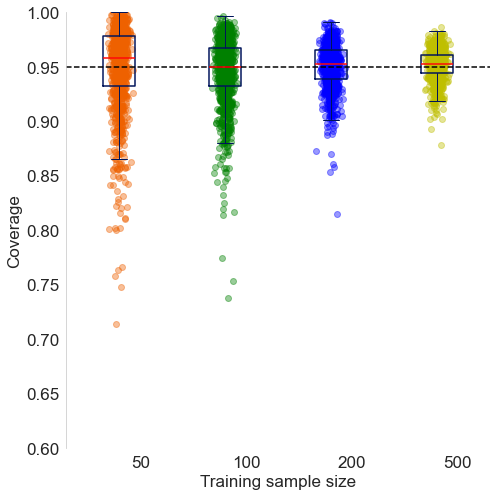

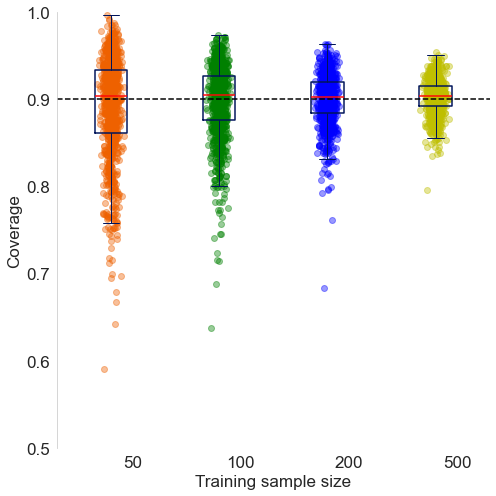

In [21]:
##### Set style options here #####
boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
flierprops = dict(marker='o', markersize=1, linestyle='none')
whiskerprops = dict(color='#00145A')
capprops = dict(color='#00145A')
medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

for kappa_50_data, alpha_level in zip(
    [iv_pb_coverage_df_kappa_50_alpha_01, iv_pb_coverage_df_kappa_50_alpha_05, iv_pb_coverage_df_kappa_50_alpha_1],
    [0.01, 0.05, 0.1]
):
    fig = plt.figure(facecolor="white", figsize=(7, 7))
    ax = fig.add_subplot(111)
    sns.despine(bottom=True)  # Remove right and top axis lines
    sns.set_style("whitegrid")
    # Extract data for each training size
    train_sizes = [50, 100, 200, 500]
    kappa_50_boxplot_data = [kappa_50_data[kappa_50_data['train_size'] == size]['iv_cov'].values for size in train_sizes]

    # Create boxplots with adjusted positions
    positions_kappa_50 = np.array(range(len(train_sizes))) - 0.2

    ax.boxplot(kappa_50_boxplot_data, positions=positions_kappa_50, widths=0.3, notch=False, 
               boxprops=dict(color='#00145A', linestyle='-', linewidth=1.5), 
               whiskerprops=dict(color='#00145A'), capprops=dict(color='#00145A'), 
               showfliers=False,  # Updated to hide fliers
               medianprops=dict(linewidth=1.5, linestyle='-', color='#ff0808'), showmeans=False)
               
    # Scatter plot
    palette_kappa_50 = ['#ee6100', 'g', 'b', 'y']

    for i, size in enumerate(train_sizes):
        xs_kappa_50 = np.random.normal(positions_kappa_50[i], 0.04, len(kappa_50_boxplot_data[i]))

        ax.scatter(xs_kappa_50, kappa_50_boxplot_data[i], alpha=0.4, color=palette_kappa_50[i], label='Prediction balls')

    ax.set_xticks(range(len(train_sizes)))
    ax.set_xticklabels([str(size) for size in train_sizes], fontsize=17)

    if alpha_level == 0.01:
        ax.set_ylim(0.825, 1)
    elif alpha_level == 0.05:
        ax.set_ylim(0.6, 1)
    else:
        ax.set_ylim(0.5, 1)

    ax.set_xlabel('Training sample size', fontsize=17)
    ax.set_ylabel('Coverage', fontsize=17)
    ax.tick_params(labelsize=17)
    ax.axhline(y=1-alpha_level, color='black', linestyle='dashed')
    ax.grid(False)

    # Custom legend
    #legend_handles = [
    #    mpatches.Patch(color=palette_kappa_50[j], label=f'Train Size: {train_sizes[j]}')
    #    for j in range(len(train_sizes))
    #]

    legend_handles = []
        
    fig.tight_layout()
    filename = os.path.join(os.getcwd(),'provisional_3_H2' + str(alpha_level)[2:] + '.pdf')
    fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
    plt.show()